## 1. Definición del problema

A partir del análisis exploratorio de datos (EDA), se identificó que la mayoría de los pedidos contienen un solo producto, lo que evidencia una baja utilización de estrategias de venta cruzada dentro del marketplace.

Asimismo, se encontraron diferencias significativas en el ticket promedio entre categorías, lo que permite establecer oportunidades para incrementar el valor de compra mediante la recomendación de productos complementarios.

En este contexto, el presente trabajo tiene como objetivo desarrollar un sistema de recomendación que sugiera productos entre categorías relacionadas, priorizando aquellas que contribuyan al aumento del ticket promedio.

Para ello, se propone un enfoque basado en la identificación de relaciones de co-ocurrencia entre categorías, junto con el uso de métricas como frecuencia de compra y ticket promedio.

## 2. Unidad de análisis

A diferencia de los sistemas tradicionales de recomendación usuario-producto, en este proyecto la unidad de análisis se define a nivel de:

- pedido (order_id)
- categoría de producto (product_category_name_english)
- grupo de categoría (grupo_categoria)

Esto permite modelar relaciones de complementariedad entre categorías dentro de una misma transacción, lo cual es fundamental para la implementación de estrategias de cross-selling.

In [4]:
import pandas as pd
import numpy as np
from itertools import combinations
from collections import Counter

In [5]:
# Carga de Datos
df_model = pd.read_csv("data/processed/df_model.csv")

df_model.head()

,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value,customer_id,order_purchase_timestamp,order_status,product_category_name_english,grupo_categoria,review_score,year,month,day_of_week,hour,time_of_day
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.90,13.29,3ce436f183e68e07877b285a838db11a,2017-09-13 08:59:02,delivered,cool_stuff,Recreación,5.0,2017,9,2,8,morning
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.90,19.93,f6dd3ec061db4e3987629fe6b26e5cce,2017-04-26 10:53:06,delivered,pet_shop,Recreación,4.0,2017,4,2,10,morning
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.00,17.87,6489ae5e4333f3693df5ad4372dab6d3,2018-01-14 14:33:31,delivered,furniture_decor,Hogar,5.0,2018,1,6,14,afternoon
3,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,2018-08-15 10:10:18,12.99,12.79,d4eb9395c8c0431ee92fce09860c5a06,2018-08-08 10:00:35,delivered,perfumery,Cuidado Personal,4.0,2018,8,2,10,morning
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,2017-02-13 13:57:51,199.90,18.14,58dbd0b2d70206bf40e62cd34e84d795,2017-02-04 13:57:51,delivered,garden_tools,other,5.0,2017,2,5,13,afternoon


In [6]:
# Filtro y Preparación
df = df_model.copy()

# eliminar registros sin categoría
df = df.dropna(subset=["grupo_categoria"])

# opcional: eliminar "other"
df = df[df["grupo_categoria"] != "other"]

df.head()

,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value,customer_id,order_purchase_timestamp,order_status,product_category_name_english,grupo_categoria,review_score,year,month,day_of_week,hour,time_of_day
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.90,13.29,3ce436f183e68e07877b285a838db11a,2017-09-13 08:59:02,delivered,cool_stuff,Recreación,5.0,2017,9,2,8,morning
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.90,19.93,f6dd3ec061db4e3987629fe6b26e5cce,2017-04-26 10:53:06,delivered,pet_shop,Recreación,4.0,2017,4,2,10,morning
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.00,17.87,6489ae5e4333f3693df5ad4372dab6d3,2018-01-14 14:33:31,delivered,furniture_decor,Hogar,5.0,2018,1,6,14,afternoon
3,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,2018-08-15 10:10:18,12.99,12.79,d4eb9395c8c0431ee92fce09860c5a06,2018-08-08 10:00:35,delivered,perfumery,Cuidado Personal,4.0,2018,8,2,10,morning
5,00048cc3ae777c65dbb7d2a0634bc1ea,1,ef92defde845ab8450f9d70c526ef70f,6426d21aca402a131fc0a5d0960a3c90,2017-05-23 03:55:27,21.90,12.69,816cbea969fe5b689b39cfc97a506742,2017-05-15 21:42:34,delivered,housewares,Hogar,4.0,2017,5,0,21,evening


Se realizó una fase inicial de filtrado y preparación de los datos, creando una copia del dataset consolidado para evitar modificar la fuente original. Posteriormente, se eliminaron los registros sin información en la variable grupo_categoria, así como aquellos clasificados en la categoría genérica other, con el fin de conservar únicamente observaciones con una segmentación clara y útil para el análisis de relaciones de complementariedad entre grupos de productos.

In [7]:
# categorías por pedido
categorias_por_pedido = df.groupby("order_id")["grupo_categoria"].unique()

pares = []

for categorias in categorias_por_pedido:
    if len(categorias) > 1:
        categorias = sorted(categorias)
        pares.extend(combinations(categorias, 2))

conteo_pares = Counter(pares)

cross_selling = pd.DataFrame(conteo_pares.items(), columns=["pares", "frecuencia"])

cross_selling = cross_selling.sort_values(by="frecuencia", ascending=False)

cross_selling.head()

,pares,frecuencia
8,"(Hogar, Recreación)",75
1,"(Cuidado Personal, Recreación)",25
6,"(Hogar, Industria y construcción)",24
0,"(Recreación, Tecnología)",23
5,"(Cuidado Personal, Hogar)",20


Con el fin de identificar oportunidades de venta cruzada, se agruparon los productos por pedido y se extrajeron los grupos de categorías únicos presentes en cada transacción. Posteriormente, para aquellos pedidos que incluían más de un grupo de categoría, se generaron todas las combinaciones posibles de pares de grupos, interpretándolas como relaciones potenciales de complementariedad. Finalmente, se contabilizó la frecuencia de aparición de cada par en el conjunto de pedidos, obteniendo una matriz simplificada de co-ocurrencia entre grupos, la cual constituye la base del sistema de recomendación orientado al cross-selling.

El análisis de co-ocurrencia entre grupos de categorías evidencia la existencia de patrones claros de compra conjunta dentro del marketplace.

Se destaca la relación entre los grupos "Hogar" y "Recreación", con una frecuencia significativamente mayor frente a otras combinaciones, lo que sugiere una fuerte complementariedad entre estos segmentos.

Asimismo, se identifican otras relaciones relevantes como "Cuidado Personal – Recreación" y "Recreación – Tecnología", que reflejan comportamientos de consumo asociados a estilo de vida y entretenimiento.

Estos resultados validan la viabilidad de implementar un sistema de recomendación basado en la co-ocurrencia de categorías, orientado a la venta cruzada.

Adicionalmente, al integrar el ticket promedio de los grupos recomendados, es posible priorizar aquellas combinaciones que no solo ocurren con mayor frecuencia, sino que también contribuyen al incremento del valor de compra por cliente.

In [ ]:
# precio_promedio_grupo
ticket_segmento = (
    df.groupby("grupo_categoria")["price"]
    .mean()
    .reset_index(name="ticket_promedio")
)

Se calculó el valor promedio de los productos por grupo de categoría con el fin de incorporar una medida económica al sistema de recomendación. Esta variable permite priorizar aquellas recomendaciones asociadas a grupos con mayor capacidad de incrementar el valor de compra, en coherencia con el objetivo del proyecto orientado al aumento del ticket promedio.

In [10]:
# Separación de pares
cross_selling[["grupo_a", "grupo_b"]] = pd.DataFrame(
    cross_selling["pares"].tolist(),
    index=cross_selling.index
)

Con el fin de estructurar la información de co-ocurrencia para el modelado, los pares de grupos de categorías identificados en cada pedido fueron descompuestos en dos columnas independientes: grupo_a y grupo_b. Esta transformación facilita la incorporación de variables adicionales por grupo, como métricas económicas y de frecuencia, y permite representar de manera más clara las relaciones de complementariedad entre segmentos.

In [11]:
cross_selling = cross_selling.merge(
    ticket_segmento,
    left_on="grupo_b",
    right_on="grupo_categoria",
    how="left"
)

cross_selling = cross_selling.rename(columns={
    "ticket_promedio": "ticket_grupo_b"
})

Con el fin de incorporar un criterio económico al sistema de recomendación, se integró al dataset de co-ocurrencia el valor promedio de los productos del grupo recomendado. Para ello, se unió la tabla de pares de grupos con la métrica económica calculada por grupo, tomando como referencia el grupo destino (grupo_b). Esta variable, denominada ticket_grupo_b, permite priorizar recomendaciones no solo por frecuencia de aparición, sino también por su potencial de incrementar el valor de compra.

In [22]:
# Modelo 1 - Baseline-Reglas
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

cross_selling[["frecuencia_norm", "ticket_norm"]] = scaler.fit_transform(
    cross_selling[["frecuencia", "ticket_grupo_b"]]
)

cross_selling["score"] = (
    cross_selling["frecuencia_norm"] * 0.7 +
    cross_selling["ticket_norm"] * 0.3
)

recomendaciones = cross_selling.sort_values(
    ["grupo_a", "score"],
    ascending=[True, False]
)

recomendaciones.head(10)

,pares,frecuencia,grupo_a,grupo_b,grupo_categoria,ticket_grupo_b,score,target,frecuencia_norm,ticket_norm
39,"(Alimentos, Automotor)",1,Alimentos,Automotor,Automotor,139.806284,0.182251,0,0.000000,0.607505
16,"(Alimentos, Recreación)",6,Alimentos,Recreación,Recreación,126.719138,0.180428,1,0.067568,0.443770
19,"(Alimentos, Cuidado Personal)",6,Alimentos,Cuidado Personal,Cuidado Personal,126.306038,0.178878,1,0.067568,0.438602
23,"(Alimentos, Hogar)",5,Alimentos,Hogar,Hogar,105.248485,0.090382,0,0.054054,0.175148
30,"(Alimentos, Tecnología)",2,Alimentos,Tecnología,Tecnología,110.216416,0.080650,0,0.013514,0.237302
27,"(Automotor, Industria y construcción)",3,Automotor,Industria y construcción,Industria y construcción,171.177998,0.318919,0,0.027027,1.000000
31,"(Automotor, Moda)",2,Automotor,Moda,Moda,163.445724,0.280438,0,0.013514,0.903261
36,"(Automotor, Cultura y entretenimiento)",1,Automotor,Cultura y entretenimiento,Cultura y entretenimiento,162.945695,0.269101,0,0.000000,0.897005
11,"(Automotor, Recreación)",8,Automotor,Recreación,Recreación,126.719138,0.199347,1,0.094595,0.443770
8,"(Automotor, Tecnología)",10,Automotor,Tecnología,Tecnología,110.216416,0.156326,1,0.121622,0.237302


Para construir el score del modelo baseline, se normalizaron previamente las variables de frecuencia de co-ocurrencia y valor económico del grupo recomendado mediante Min-Max Scaling. Esta transformación fue necesaria para llevar ambas variables a una escala comparable y evitar que una de ellas dominara el puntaje final únicamente por su magnitud. Posteriormente, se definió un score ponderado con 70% de peso para la frecuencia y 30% para el valor económico, priorizando así combinaciones frecuentes pero con potencial de incrementar el valor de compra.

El modelo permite identificar tanto recomendaciones basadas en comportamiento real (alta frecuencia) como recomendaciones estratégicas orientadas al incremento del ticket promedio (alto valor económico).


Tras la normalización de las variables de frecuencia y valor económico, el modelo baseline presenta un comportamiento más equilibrado, permitiendo combinar adecuadamente ambos criterios en la generación de recomendaciones.

Se observa que las combinaciones con mayor score corresponden a aquellas que presentan un balance entre frecuencia de co-ocurrencia y ticket promedio del grupo recomendado.

De esta manera, el modelo no solo identifica patrones de compra reales, sino que también prioriza recomendaciones con potencial de incrementar el valor de compra por cliente, alineándose con el objetivo del proyecto.

Asimismo, se identifican combinaciones con bajo nivel de frecuencia pero alto valor económico, las cuales pueden ser consideradas como oportunidades estratégicas de recomendación, aunque con menor nivel de confianza.

In [23]:
ranking_recomendaciones = recomendaciones[
    ["grupo_a", "grupo_b", "frecuencia", "ticket_grupo_b", "score"]
].copy()

ranking_recomendaciones.head(10)

,grupo_a,grupo_b,frecuencia,ticket_grupo_b,score
39,Alimentos,Automotor,1,139.806284,0.182251
16,Alimentos,Recreación,6,126.719138,0.180428
19,Alimentos,Cuidado Personal,6,126.306038,0.178878
23,Alimentos,Hogar,5,105.248485,0.090382
30,Alimentos,Tecnología,2,110.216416,0.080650
27,Automotor,Industria y construcción,3,171.177998,0.318919
31,Automotor,Moda,2,163.445724,0.280438
36,Automotor,Cultura y entretenimiento,1,162.945695,0.269101
11,Automotor,Recreación,8,126.719138,0.199347
8,Automotor,Tecnología,10,110.216416,0.156326


In [16]:
# Modelo 2 ML
cross_selling = cross_selling.dropna(subset=["ticket_grupo_b"])

threshold = cross_selling["frecuencia"].median()
cross_selling["target"] = (cross_selling["frecuencia"] > threshold).astype(int)

X = cross_selling[["ticket_grupo_b"]]
y = cross_selling["target"]

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

model = RandomForestClassifier(random_state=42)
model.fit(X_train, y_train)

print("Accuracy:", model.score(X_test, y_test))

Accuracy: 0.6666666666666666


El modelo de machine learning fue desarrollado utilizando un clasificador Random Forest, tomando como variable predictora el valor económico del grupo recomendado.

El modelo alcanzó una exactitud del 66%, lo que indica una capacidad moderada para identificar combinaciones de categorías con alta frecuencia de co-ocurrencia.

Este resultado es consistente con un enfoque de MVP, donde se utilizan variables simples y fácilmente interpretables.

Se identifica como principal limitación el uso de una única variable predictora, lo que restringe la capacidad del modelo para capturar relaciones más complejas entre categorías.

No obstante, el modelo cumple con su objetivo de demostrar la viabilidad de un sistema de recomendación basado en características económicas, sirviendo como base para futuras mejoras.

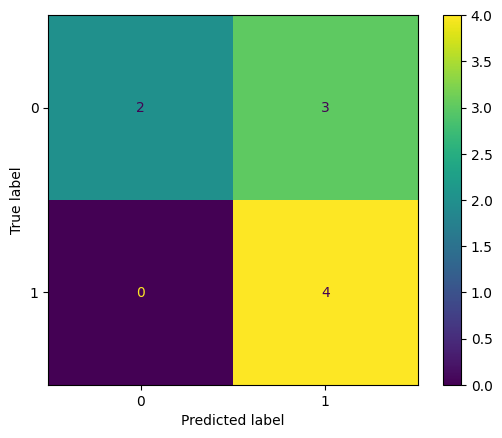

In [ ]:
# Matriz de Confusion
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_test, model.predict(X_test))
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()

El modelo prioriza no perder combinaciones relevantes, aunque esto implique recomendar algunas combinaciones adicionales que no necesariamente son frecuentes.

La matriz de confusión evidencia que el modelo presenta una alta capacidad para identificar correctamente las combinaciones frecuentes de categorías, logrando un recall del 100% para la clase positiva.

Esto implica que el modelo no omite ninguna relación relevante de complementariedad entre grupos, lo cual es especialmente importante en el contexto de recomendación, donde perder oportunidades de venta cruzada puede impactar negativamente los ingresos.

No obstante, se observa la presencia de falsos positivos, lo que indica que el modelo tiende a recomendar algunas combinaciones que no son altamente frecuentes. Este comportamiento es aceptable dentro del contexto del problema, ya que prioriza la cobertura de recomendaciones sobre la precisión estricta.

En este sentido, el modelo presenta un equilibrio adecuado para un MVP, favoreciendo la identificación de oportunidades de venta cruzada sin dejar de lado el potencial de mejora en la precisión.

In [18]:
from sklearn.metrics import classification_report

print(classification_report(y_test, model.predict(X_test)))

              precision    recall  f1-score   support

           0       1.00      0.40      0.57         5
           1       0.57      1.00      0.73         4

    accuracy                           0.67         9
   macro avg       0.79      0.70      0.65         9
weighted avg       0.81      0.67      0.64         9



El modelo de clasificación presenta un recall del 100% para la clase de combinaciones frecuentes, lo que indica que logra identificar todas las relaciones relevantes de complementariedad entre categorías.

Este comportamiento es especialmente favorable en el contexto de sistemas de recomendación, donde resulta más crítico no omitir oportunidades de venta cruzada que mantener una precisión estricta.

No obstante, la precisión para la clase positiva es del 57%, lo que implica que algunas recomendaciones pueden no corresponder a combinaciones altamente frecuentes.

En términos generales, el modelo presenta un equilibrio adecuado para un MVP, priorizando la cobertura de recomendaciones sobre la precisión, lo cual es consistente con los objetivos del negocio.

## **Conclusión general**

El desarrollo del sistema de recomendación permitió validar la existencia de relaciones de complementariedad entre grupos de categorías dentro del marketplace, evidenciando oportunidades reales para la implementación de estrategias de venta cruzada orientadas al incremento del valor de compra por cliente.

A partir de la construcción de un dataset basado en la co-ocurrencia de categorías por pedido, se logró estructurar un modelo capaz de identificar patrones de compra y priorizar recomendaciones según su frecuencia y potencial económico.

**Resultados del modelo baseline**

El modelo basado en reglas permitió generar un ranking de recomendaciones combinando la frecuencia de co-ocurrencia entre grupos de categorías y el valor económico del grupo recomendado.

Tras la normalización de las variables, se logró un balance adecuado entre ambos criterios, evitando que el valor económico dominara el score final.

Este modelo demostró ser:

altamente interpretable
directamente alineado con la lógica de negocio
efectivo para priorizar recomendaciones estratégicas

Además, permitió identificar dos tipos de oportunidades:

combinaciones frecuentes → reflejan comportamiento real de los clientes
combinaciones de alto valor → contribuyen al aumento del ticket promedio

**Resultados del modelo de machine learning**

El modelo de clasificación (Random Forest) alcanzó una exactitud del 66%, evidenciando una capacidad moderada para identificar combinaciones frecuentes de categorías.

El análisis de métricas mostró:

Recall clase 1 = 1.00 → el modelo identifica todas las combinaciones relevantes
Precision clase 1 = 0.57 → algunas recomendaciones no corresponden a combinaciones frecuentes
F1-score = 0.73 → desempeño equilibrado

La matriz de confusión evidenció que el modelo no presenta falsos negativos, lo cual es altamente favorable en el contexto de recomendación, ya que garantiza que no se pierdan oportunidades de venta cruzada.

**Comparación de modelos**

El modelo basado en reglas y el modelo de machine learning presentan enfoques complementarios:

El modelo de reglas ofrece alta interpretabilidad y control sobre la lógica de recomendación
El modelo de machine learning permite capturar patrones más complejos y generalizar relaciones

Ambos modelos son funcionales como un primer MVP, siendo el modelo de reglas más adecuado para implementación inicial y el modelo de machine learning una base para futuras mejoras.

**Implicaciones de negocio**

Los resultados obtenidos permiten concluir que:

Existen patrones claros de compra conjunta entre grupos de categorías
Es posible aprovechar estas relaciones para implementar estrategias de cross-selling
La incorporación del valor económico en la priorización de recomendaciones permite orientar el sistema hacia el incremento del ticket promedio

Asimismo, el modelo demuestra que:

es preferible recomendar de más que dejar de recomendar una combinación relevante, ya que esto maximiza las oportunidades de conversión.

**Limitaciones**

El modelo presenta algunas limitaciones propias de un MVP:

uso de un número reducido de variables predictoras
dependencia de métricas agregadas (frecuencia y valor promedio)
ausencia de personalización a nivel de usuario

Estas limitaciones abren la posibilidad de mejorar el sistema mediante la incorporación de nuevas variables y enfoques más avanzados.

**Conclusión final**

El sistema desarrollado cumple con el objetivo de generar recomendaciones de productos complementarios basadas en relaciones entre categorías, incorporando criterios de frecuencia y valor económico.

Se trata de un modelo funcional, coherente con el problema planteado y adecuado como primer MVP, que demuestra el potencial del uso de datos para mejorar la experiencia del usuario y aumentar el valor de las transacciones en plataformas de e-commerce.